### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [2]:
titanic = sns.load_dataset("titanic")

print(titanic.columns)
print(titanic.info())
print(titanic.head())

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [3]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
titanic.fillna({"age" : titanic["age"].mean()}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
titanic["age"].isnull().sum()

np.int64(0)

In [7]:
titanic["embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [8]:
titanic["embarked"].isnull().sum()

np.int64(2)

In [9]:
titanic.fillna({"embarked" : "N"}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [10]:
titanic["embarked"].isnull().sum()

np.int64(0)

In [11]:
titanic["deck"] = titanic["deck"].cat.add_categories("N")
titanic.fillna({"deck": "N"}, inplace=True)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [12]:
titanic["deck"].isnull().sum()

np.int64(0)

In [13]:
titanic["deck"].value_counts()

deck
N    688
C     59
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [14]:
titanic.fillna({"embark_town" : "N"}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [15]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [16]:
titanic["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [17]:
titanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [18]:
titanic.groupby("sex")["survived"].value_counts()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [19]:
titanic.groupby(["sex", "survived"])["survived"].count()

sex     survived
female  0            81
        1           233
male    0           468
        1           109
Name: survived, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

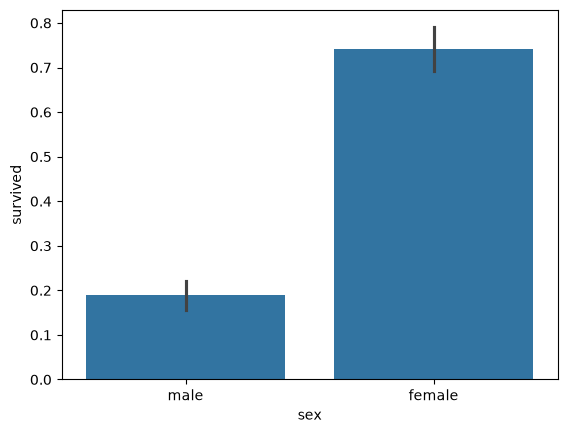

In [20]:
sns.barplot(data=titanic, x="sex", y="survived")

<Axes: xlabel='pclass', ylabel='survived'>

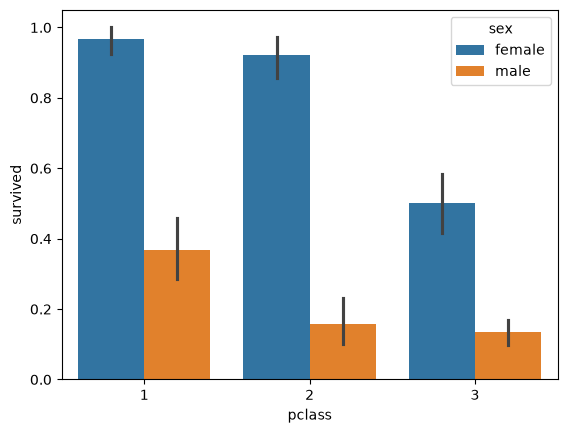

In [21]:
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex")

## 객실 등급별 성별에 따른 생존 확률
- 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.
- 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.
- 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

In [22]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()

label_cols = ["sex", "embarked", "class", "who", "deck", "embark_town"]

for col in label_cols:
    titanic_df1[col] = le.fit_transform(titanic_df1[col])

In [24]:
titanic_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10), str(1)
memory usage: 92.4 KB


In [25]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,3,2,1,7,3
1,0,0,0,2,2,0
2,0,3,2,2,7,3
3,0,3,0,2,2,3
4,1,3,2,1,7,3


In [26]:
print(titanic["sex"].head())
print(titanic_df1["sex"].head())

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str
0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


In [27]:
titanic_df1["sex"].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [28]:
titanic_df1["deck"].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
titanic_df2 = titanic.copy()
ohe_cols = ["sex", "embarked", "class", "who", "deck", "embark_town"]

ohe_result = pd.DataFrame(index=titanic_df2.index)

for col in ohe_cols:
    encoded = ohe.fit_transform(titanic_df2[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=ohe_result.index)

    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

In [30]:
print(len(ohe_result.columns))
print(ohe_result.head())

24
   sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0         0.0       1.0         0.0         0.0         0.0         1.0   
1         1.0       0.0         1.0         0.0         0.0         0.0   
2         1.0       0.0         0.0         0.0         0.0         1.0   
3         1.0       0.0         0.0         0.0         0.0         1.0   
4         0.0       1.0         0.0         0.0         0.0         1.0   

   class_First  class_Second  class_Third  who_child  ...  deck_C  deck_D  \
0          0.0           0.0          1.0        0.0  ...     0.0     0.0   
1          1.0           0.0          0.0        0.0  ...     1.0     0.0   
2          0.0           0.0          1.0        0.0  ...     0.0     0.0   
3          1.0           0.0          0.0        0.0  ...     1.0     0.0   
4          0.0           0.0          1.0        0.0  ...     0.0     0.0   

   deck_E  deck_F  deck_G  deck_N  embark_town_Cherbourg  embark_town_N  \
0     0.

In [31]:
titanic_df2.drop(columns=["alive"], inplace=True)

In [32]:
titanic_df2.drop(columns=ohe_cols, inplace=True)

In [33]:
titanic_df2 = pd.concat([titanic_df2, ohe_result], axis=1)
titanic_df2

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.000000,1,0,7.2500,True,False,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,1,38.000000,1,0,71.2833,False,False,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.000000,0,0,7.9250,False,True,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1,1,35.000000,1,0,53.1000,False,False,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,3,35.000000,0,0,8.0500,True,True,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,True,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
887,1,1,19.000000,0,0,30.0000,False,True,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
888,0,3,29.699118,1,2,23.4500,False,False,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
889,1,1,26.000000,0,0,30.0000,True,True,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [34]:
titanic_df2.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N',
       'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='str')

In [35]:
print(len(titanic_df2.columns))

32


| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `alive`       | str   | LabelEncoder  | yes/no → 이진             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |


In [36]:
titanic_df3 = titanic.copy()
titanic_df3.drop(columns=["alive"], inplace=True)

In [37]:
titanic_df3 = titanic.copy()

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alone']
le = LabelEncoder()

for col in label_cols:
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과를 저장할 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols:
    #encoded 타입은 ndarray
    encoded = ohe.fit_transform(titanic_df3[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df3.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

# 기존 원본 컬럼 삭제 후 병합
titanic_df3 = pd.concat([titanic_df3.drop(columns=ohe_cols), ohe_result], axis=1)
print(titanic_df3.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 891 non-null    int64  
 1   pclass                   891 non-null    int64  
 2   age                      891 non-null    float64
 3   sibsp                    891 non-null    int64  
 4   parch                    891 non-null    int64  
 5   fare                     891 non-null    float64
 6   class                    891 non-null    int64  
 7   adult_male               891 non-null    int64  
 8   alive                    891 non-null    str    
 9   alone                    891 non-null    int64  
 10  sex_female               891 non-null    float64
 11  sex_male                 891 non-null    float64
 12  embarked_C               891 non-null    float64
 13  embarked_N               891 non-null    float64
 14  embarked_Q               891 non-null

In [38]:
titanic_df3.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class',
       'adult_male', 'alive', 'alone', 'sex_female', 'sex_male', 'embarked_C',
       'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man',
       'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F',
       'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N',
       'embark_town_Queenstown', 'embark_town_Southampton'],
      dtype='str')

In [39]:
titanic_df3.head(3)

,survived,pclass,age,sibsp,parch,fare,class,adult_male,alive,alone,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,2,1,no,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,0,0,yes,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,2,0,yes,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.  
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.  

make_column_transformer를 이용한 인코딩
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

In [40]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()

In [41]:
titanic_df4.drop(columns=["alive"], inplace=True)

In [42]:
titanic_df4.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='str')

In [43]:
onehot_cols = ["sex", "embarked", "who", "deck", "embark_town"]
ordinal_cols = ["class", "adult_male", "alone"]

# make_column_transformer
column_transformer = make_column_transformer((OneHotEncoder(sparse_output=False, handle_unknown='ignore'), onehot_cols),(OrdinalEncoder(), ordinal_cols), remainder="passthrough")

# 변환 적용
encoded = column_transformer.fit_transform(titanic_df4)

In [44]:
encoded

array([[ 0.    ,  1.    ,  0.    , ...,  1.    ,  0.    ,  7.25  ],
       [ 1.    ,  0.    ,  1.    , ...,  1.    ,  0.    , 71.2833],
       [ 1.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 1.    ,  0.    ,  0.    , ...,  1.    ,  2.    , 23.45  ],
       [ 0.    ,  1.    ,  1.    , ...,  0.    ,  0.    , 30.    ],
       [ 0.    ,  1.    ,  0.    , ...,  0.    ,  0.    ,  7.75  ]],
      shape=(891, 30))

In [45]:
titanic_df4

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [46]:
column_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [47]:
onehot_feature_names = column_transformer.named_transformers_["onehotencoder"].get_feature_names_out(onehot_cols)
print(f"onehot_feature_names : {onehot_feature_names}")

onehot_feature_names : ['sex_female' 'sex_male' 'embarked_C' 'embarked_N' 'embarked_Q'
 'embarked_S' 'who_child' 'who_man' 'who_woman' 'deck_A' 'deck_B' 'deck_C'
 'deck_D' 'deck_E' 'deck_F' 'deck_G' 'deck_N' 'embark_town_Cherbourg'
 'embark_town_N' 'embark_town_Queenstown' 'embark_town_Southampton']


In [48]:
ordinal_feature_names = ordinal_cols
print(f"oridinal_feature_names : {ordinal_feature_names}")

oridinal_feature_names : ['class', 'adult_male', 'alone']


In [49]:
other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols]

final_feature_names = other_feature_name + list(onehot_feature_names) + ordinal_feature_names

print(f"final_feature_names : {final_feature_names}")

final_feature_names : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown', 'embark_town_Southampton', 'class', 'adult_male', 'alone']


In [50]:
titanic_df4 = pd.DataFrame(encoded, columns=final_feature_names, index=titanic_df4.index)
titanic_df4

,survived,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_N,...,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton,class,adult_male,alone
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,2.0,1.0,0.0,0.0,3.0,22.000000,1.0,0.0,7.2500
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,38.000000,1.0,0.0,71.2833
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,2.0,0.0,1.0,1.0,3.0,26.000000,0.0,0.0,7.9250
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,35.000000,1.0,0.0,53.1000
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,2.0,1.0,1.0,0.0,3.0,35.000000,0.0,0.0,8.0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,2.0,27.000000,0.0,0.0,13.0000
887,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,19.000000,0.0,0.0,30.0000
888,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,2.0,0.0,0.0,0.0,3.0,29.699118,1.0,2.0,23.4500
889,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,26.000000,0.0,0.0,30.0000


In [51]:
feature_names = column_transformer.get_feature_names_out()
print(feature_names)

['onehotencoder__sex_female' 'onehotencoder__sex_male'
 'onehotencoder__embarked_C' 'onehotencoder__embarked_N'
 'onehotencoder__embarked_Q' 'onehotencoder__embarked_S'
 'onehotencoder__who_child' 'onehotencoder__who_man'
 'onehotencoder__who_woman' 'onehotencoder__deck_A'
 'onehotencoder__deck_B' 'onehotencoder__deck_C' 'onehotencoder__deck_D'
 'onehotencoder__deck_E' 'onehotencoder__deck_F' 'onehotencoder__deck_G'
 'onehotencoder__deck_N' 'onehotencoder__embark_town_Cherbourg'
 'onehotencoder__embark_town_N' 'onehotencoder__embark_town_Queenstown'
 'onehotencoder__embark_town_Southampton' 'ordinalencoder__class'
 'ordinalencoder__adult_male' 'ordinalencoder__alone'
 'remainder__survived' 'remainder__pclass' 'remainder__age'
 'remainder__sibsp' 'remainder__parch' 'remainder__fare']


In [52]:
encoded_df_default = pd.DataFrame(encoded, columns=feature_names)
print(encoded_df_default.columns)

Index(['onehotencoder__sex_female', 'onehotencoder__sex_male',
       'onehotencoder__embarked_C', 'onehotencoder__embarked_N',
       'onehotencoder__embarked_Q', 'onehotencoder__embarked_S',
       'onehotencoder__who_child', 'onehotencoder__who_man',
       'onehotencoder__who_woman', 'onehotencoder__deck_A',
       'onehotencoder__deck_B', 'onehotencoder__deck_C',
       'onehotencoder__deck_D', 'onehotencoder__deck_E',
       'onehotencoder__deck_F', 'onehotencoder__deck_G',
       'onehotencoder__deck_N', 'onehotencoder__embark_town_Cherbourg',
       'onehotencoder__embark_town_N', 'onehotencoder__embark_town_Queenstown',
       'onehotencoder__embark_town_Southampton', 'ordinalencoder__class',
       'ordinalencoder__adult_male', 'ordinalencoder__alone',
       'remainder__survived', 'remainder__pclass', 'remainder__age',
       'remainder__sibsp', 'remainder__parch', 'remainder__fare'],
      dtype='str')


In [53]:
titanic_df5 = titanic.copy()

column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder="passthrough",
    verbose_feature_names_out=False
)

encoded = column_transformer_ignore.fit_transform(titanic_df5)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(f'encoded_df.columns : {encoded_df.columns}')
print(encoded)

encoded_df.columns : Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare', 'alive'],
      dtype='str')
[[0.0 1.0 0.0 ... 0 7.25 'no']
 [1.0 0.0 1.0 ... 0 71.2833 'yes']
 [1.0 0.0 0.0 ... 0 7.925 'yes']
 ...
 [1.0 0.0 0.0 ... 2 23.45 'no']
 [0.0 1.0 1.0 ... 0 30.0 'yes']
 [0.0 1.0 0.0 ... 0 7.75 'no']]


ColumnTransformer는 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [54]:
from sklearn.compose import ColumnTransformer

titanic_df6 = titanic.copy()
titanic_df6.drop(columns=["alive"], inplace=True)

In [55]:
titanic_df6.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,N,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,N,Southampton,True


In [56]:
target = titanic_df6["survived"]
titanic_df6 = titanic_df6.iloc[:, 1:]
onehot_cols = ["sex", "embarked", "who", "deck", "embark_town"]
ordinal_cols = ["class", "adult_male", "alone"]
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

In [57]:
encoded_array = ct.fit_transform(titanic_df6)

In [58]:
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)
print(encoded_df.head())

   sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0         0.0       1.0         0.0         0.0         0.0         1.0   
1         1.0       0.0         1.0         0.0         0.0         0.0   
2         1.0       0.0         0.0         0.0         0.0         1.0   
3         1.0       0.0         0.0         0.0         0.0         1.0   
4         0.0       1.0         0.0         0.0         0.0         1.0   

   who_child  who_man  who_woman  deck_A  ...  embark_town_Queenstown  \
0        0.0      1.0        0.0     0.0  ...                     0.0   
1        0.0      0.0        1.0     0.0  ...                     0.0   
2        0.0      0.0        1.0     0.0  ...                     0.0   
3        0.0      0.0        1.0     0.0  ...                     0.0   
4        0.0      1.0        0.0     0.0  ...                     0.0   

   embark_town_Southampton  class  adult_male  alone  pclass   age  sibsp  \
0                      1.0    2.0

In [59]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [60]:
# target_encoded_df = pd.concat([target, encoded_df], axis=1)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(encoded_df, target, test_size=0.25, stratify=target, shuffle=True)

print(f'train : {y_train.value_counts()[0] / y_train.value_counts()[1]}')
print(f'test : {y_test.value_counts()[0] / y_test.value_counts()[1]}')

train : 1.609375
test : 1.5930232558139534


In [62]:
reg = LogisticRegression(max_iter=1000)
reg.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [63]:
y_pred = reg.predict(X_test)


In [64]:
confusion_matrix(y_test, y_pred)

array([[120,  17],
       [ 20,  66]])

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       137
           1       0.80      0.77      0.78        86

    accuracy                           0.83       223
   macro avg       0.83      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



In [66]:

# 평가지표
print('평가지표')
print(f'Accuracy : {accuracy_score(y_test, y_pred)}')
print(f'Precision : {precision_score(y_test, y_pred)}')
print(f'Recall : {recall_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')

평가지표
Accuracy : 0.8340807174887892
Precision : 0.7951807228915663
Recall : 0.7674418604651163
F1 Score : 0.7810650887573964


/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_10252/1925037479.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, x='Coefficient', y='Feature', ax=axes[1], palette='coolwarm')


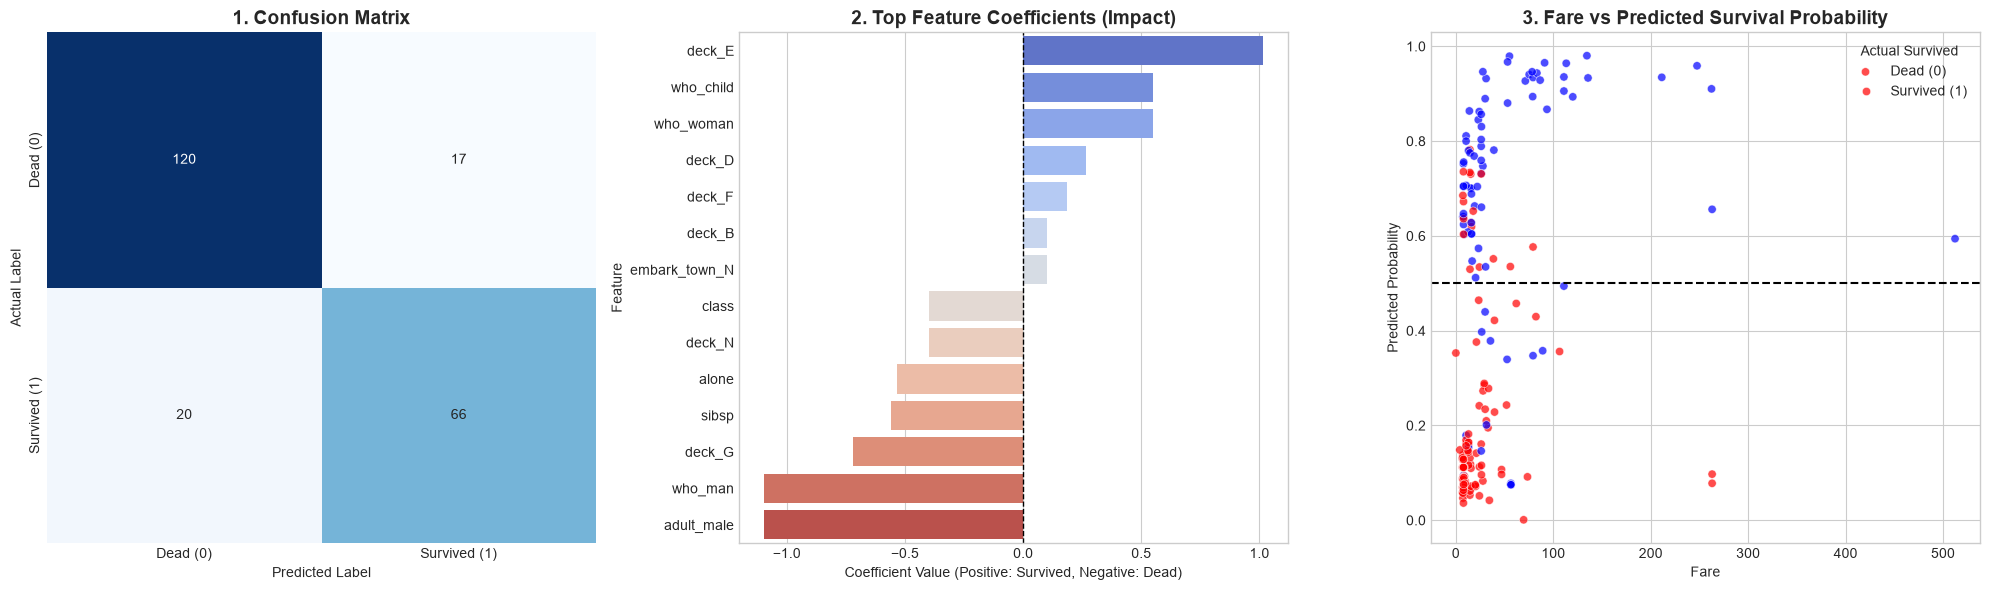

In [67]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# [그래프 1] Confusion Matrix (혼동 행렬)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Dead (0)', 'Survived (1)'],
            yticklabels=['Dead (0)', 'Survived (1)'])
axes[0].set_title("1. Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# [그래프 2] Feature Coefficients (특성별 영향력/계수 시각화)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# 상위/하위 영향력 있는 주요 변수 추출 (상위 7개, 하위 7개)
top_coef = pd.concat([coef_df.head(7), coef_df.tail(7)])

sns.barplot(data=top_coef, x='Coefficient', y='Feature', ax=axes[1], palette='coolwarm')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("2. Top Feature Coefficients (Impact)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Coefficient Value (Positive: Survived, Negative: Dead)")

# [그래프 3] Fare vs Predicted Probability (요금 대비 예측 생존 확률)
y_prob = reg.predict_proba(X_test)[:, 1]  # 생존(1)에 대한 예측 확률 추출

sns.scatterplot(x=X_test['fare'], y=y_prob, hue=y_test, palette={0: 'red', 1: 'blue'}, alpha=0.7, ax=axes[2])
axes[2].axhline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[2].set_title("3. Fare vs Predicted Survival Probability", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Fare")
axes[2].set_ylabel("Predicted Probability")
axes[2].legend(title='Actual Survived', labels=['Dead (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()